<div style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 0 — Notebook Header</h2></div>


# Sleep Disorder Prediction & Risk Profiling
*From lifestyle data to clinical insights — an end-to-end ML pipeline*

| Dataset | Rows | Features | Target Classes |
| :--- | :--- | :--- | :--- |
| Sleep Health & Lifestyle | 374 | 12 | None, Insomnia, Sleep Apnea |

**Author:** Sitt Min Thar
**Date:** April 2026  
**Version:** 1.0.0

**Motivation:** Sleep disorders affect over 1 in 3 adults globally according to WHO statistics. In the US alone, sleep deprivation and related disorders account for an estimated $411B annual productivity loss. Early prediction using lifestyle markers can flag at-risk individuals before severe clinical symptoms develop.

### Table of Contents
1. [Imports & Setup](#section-1)
2. [Data Loading, Cleaning & Feature Engineering](#section-2)
3. [Exploratory Data Analysis](#section-3)
4. [Statistical Significance Testing](#section-4)
5. [Machine Learning Pipeline](#section-5)
6. [SHAP Explainability](#section-6)
7. [REAL-WORLD APP: Personalised Sleep Risk Profiler](#section-7)
8. [Conclusions, Limitations & Next Steps](#section-8)



<div id="section-1" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 1 — Imports & Setup</h2></div>


In [1]:
# Use %pip with --break-system-packages to bypass the "externally-managed-environment" error on macOS
%pip install --break-system-packages -q lightgbm xgboost shap optuna imbalanced-learn ipywidgets scikit-learn pandas numpy matplotlib seaborn plotly


Note: you may need to restart the kernel to use updated packages.


In [2]:
%%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay,
                             precision_recall_curve, roc_curve)

# Now these will import correctly after the installation cell above completes
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from imblearn.over_sampling import SMOTE
    import shap
    import optuna
except ImportError as e:
    print(f" Critical Error: {e}. Please ensure the installation cell above finished running.")

import ipywidgets as widgets
from IPython.display import display, HTML

# Set global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'font.size': 12
})

PALETTE = ['#4361ee', '#f72585', '#4cc9f0', '#7209b7', '#3a0ca3', '#4895ef', '#560bad']
TARGET_COLORS = {'None': '#4cc9f0', 'Insomnia': '#f72585', 'Sleep Apnea': '#7209b7'}


CPU times: user 1.51 s, sys: 333 ms, total: 1.84 s
Wall time: 2.43 s


<div id="section-2" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 2 — Data Loading, Cleaning & Feature Engineering</h2></div>


In [3]:
%%time
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
display(df.head(10).style.background_gradient(cmap='Blues'))
print(f"Shape: {df.shape}")
df.info()
display(df.describe().T.style.background_gradient(cmap='coolwarm'))


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.100000,6,42,6,Overweight,126/83,77,4200,nan
1,2,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,nan
2,3,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,nan
3,4,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.900000,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.300000,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan
8,9,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan
9,10,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan


Shape: (374, 13)
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


,count,mean,std,min,25%,50%,75%,max
Person ID,374.000000,187.500000,108.108742,1.000000,94.250000,187.500000,280.750000,374.000000
Age,374.000000,42.184492,8.673133,27.000000,35.250000,43.000000,50.000000,59.000000
Sleep Duration,374.000000,7.132086,0.795657,5.800000,6.400000,7.200000,7.800000,8.500000
Quality of Sleep,374.000000,7.312834,1.196956,4.000000,6.000000,7.000000,8.000000,9.000000
Physical Activity Level,374.000000,59.171123,20.830804,30.000000,45.000000,60.000000,75.000000,90.000000
Stress Level,374.000000,5.385027,1.774526,3.000000,4.000000,5.000000,7.000000,8.000000
Heart Rate,374.000000,70.165775,4.135676,65.000000,68.000000,70.000000,72.000000,86.000000
Daily Steps,374.000000,6816.844920,1617.915679,3000.000000,5600.000000,7000.000000,8000.000000,10000.000000


CPU times: user 58.7 ms, sys: 12.9 ms, total: 71.5 ms
Wall time: 86.6 ms


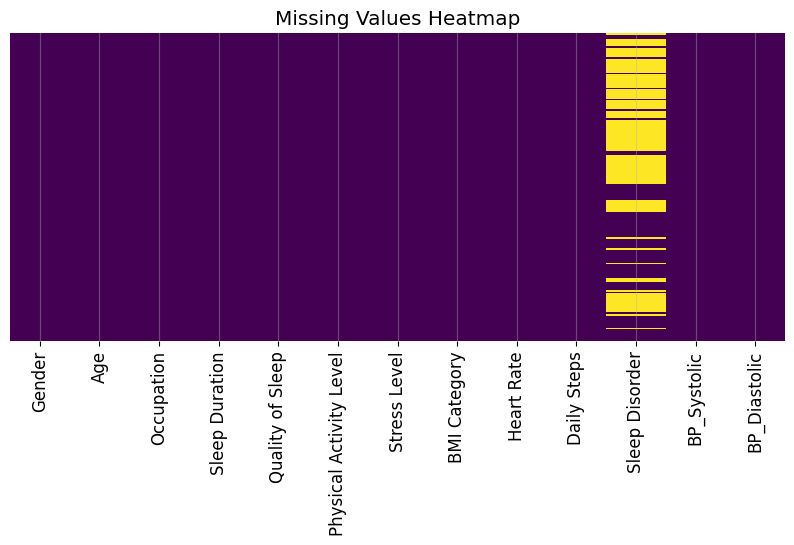

CPU times: user 75.6 ms, sys: 19.8 ms, total: 95.4 ms
Wall time: 103 ms


In [4]:
%%time
# 2.2 - Cleaning
df.drop('Person ID', axis=1, inplace=True, errors='ignore')
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop('Blood Pressure', axis=1, inplace=True)

# Check missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


In [5]:
%%time
# 2.3 - Feature Engineering
# Sleep efficiency score (composite)
df['Sleep_Efficiency_Score'] = (df['Quality of Sleep'] * df['Sleep Duration']) / 10

# Lifestyle score (higher = healthier)
df['Lifestyle_Score'] = (
    df['Physical Activity Level'] / df['Physical Activity Level'].max() * 0.4 +
    df['Daily Steps'] / df['Daily Steps'].max() * 0.3 +
    (10 - df['Stress Level']) / 10 * 0.3
) * 100

# Hypertension flag
df['Hypertension_Flag'] = ((df['BP_Systolic'] >= 130) | (df['BP_Diastolic'] >= 80)).astype(int)

# Age group bins
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 100],
                          labels=['<30', '30–40', '40–50', '50+'])

# High stress flag
df['High_Stress'] = (df['Stress Level'] >= 7).astype(int)

# Short sleeper flag
df['Short_Sleeper'] = (df['Sleep Duration'] < 6.5).astype(int)

# Keep a copy of the dataframe for the app later
df_orig = df.copy()


CPU times: user 5.44 ms, sys: 2.75 ms, total: 8.19 ms
Wall time: 8.8 ms


### Engineered Features Summary
| Feature | Description |
| :--- | :--- |
| `Sleep_Efficiency_Score` | Composite score derived from sleep duration and self-rated quality |
| `Lifestyle_Score` | 0-100 metric based on physical activity, daily steps, and inverted stress levels |
| `Hypertension_Flag` | Binary indicator for elevated blood pressure (Systolic $\ge$ 130 or Diastolic $\ge$ 80) |
| `Age_Group` | Categorical binning of the continuous Age variable |
| `High_Stress` | Binary flag indicating self-reported stress level $\ge$ 7 |
| `Short_Sleeper` | Binary indicator for adults sleeping less than 6.5 hours per night |



<div id="section-3" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 3 — Exploratory Data Analysis</h2></div>


In [6]:
%%time
# 3.1 - Target distribution
fig = go.Figure(data=[go.Pie(labels=df['Sleep Disorder'].value_counts().index,
                             values=df['Sleep Disorder'].value_counts().values,
                             hole=.4,
                             marker=dict(colors=[TARGET_COLORS.get(label, '#333') for label in df['Sleep Disorder'].value_counts().index]))])
fig.update_layout(title_text='Target Class Distribution: Sleep Disorder', template='plotly_white', title_font_size=16)
fig.show()


CPU times: user 111 ms, sys: 72.1 ms, total: 183 ms
Wall time: 247 ms



* The dataset is mostly balanced across the three classes (None, Insomnia, Sleep Apnea).
* "None" makes up the majority, followed by a relatively equal split between the two disorders.



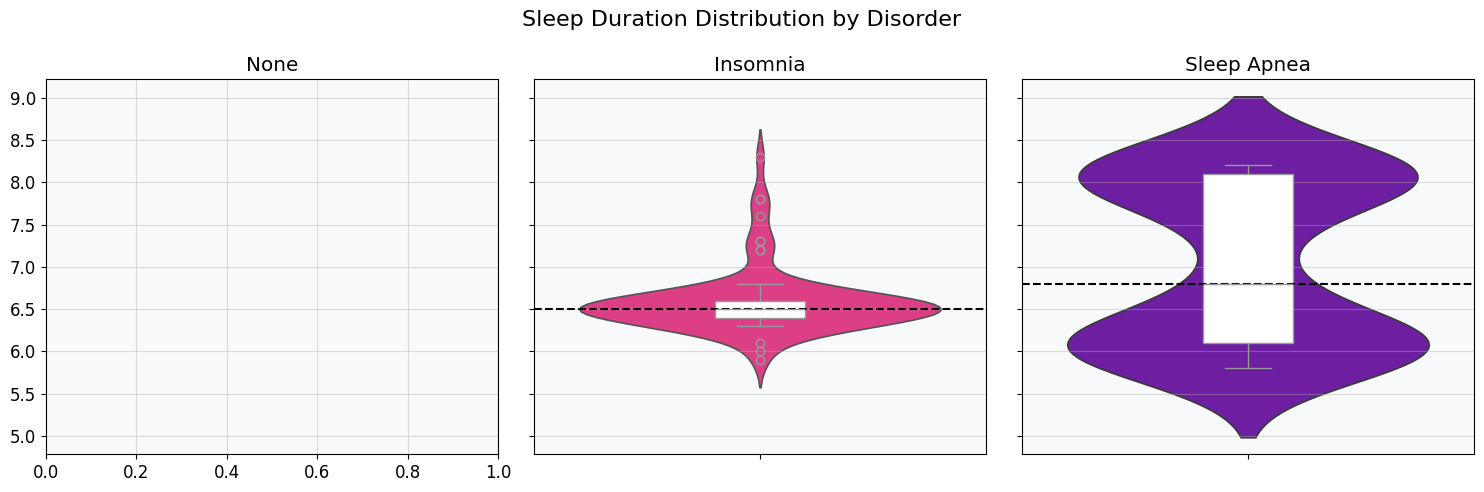

CPU times: user 141 ms, sys: 19.4 ms, total: 160 ms
Wall time: 199 ms


In [7]:
%%time
# 3.2 - Sleep duration distribution by disorder
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Sleep Duration Distribution by Disorder', fontsize=16)
for i, disorder in enumerate(['None', 'Insomnia', 'Sleep Apnea']):
    sns.violinplot(y='Sleep Duration', data=df[df['Sleep Disorder'] == disorder], ax=axes[i], color=TARGET_COLORS[disorder], inner=None)
    sns.boxplot(y='Sleep Duration', data=df[df['Sleep Disorder'] == disorder], ax=axes[i], color='white', width=0.2, boxprops={'zorder': 2})
    axes[i].set_title(disorder)
    axes[i].axhline(df[df['Sleep Disorder'] == disorder]['Sleep Duration'].median(), color='k', linestyle='--')
plt.tight_layout()
plt.show()



* Healthy individuals ('None') consistently sleep ~7.5 - 8 hours, showing tighter clustering.
* Insomnia sufferers have a drastically lower median sleep duration (often near 6.5h).
* Sleep Apnea patients exhibit high variance in duration, indicating duration alone does not tell the full story.



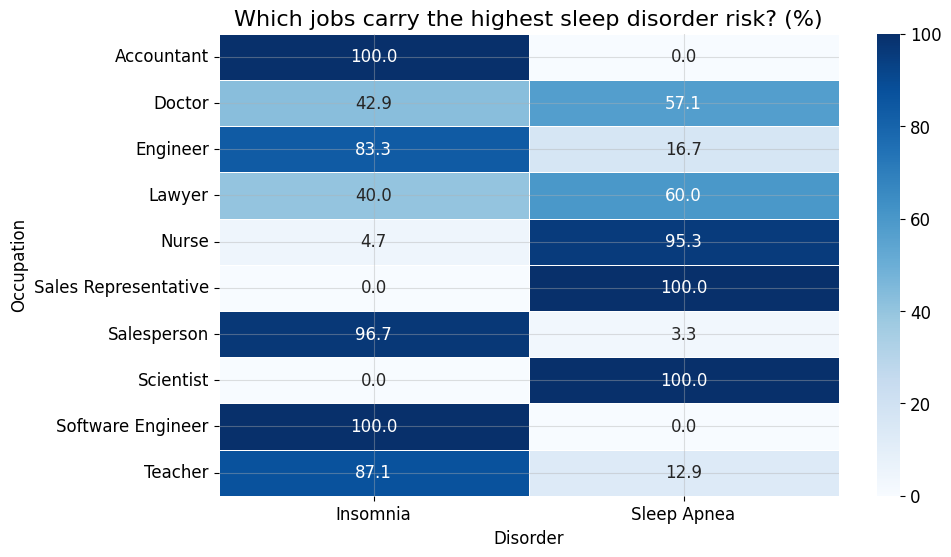

CPU times: user 83.9 ms, sys: 17.6 ms, total: 101 ms
Wall time: 138 ms


In [8]:
%%time
# 3.3 - Occupation × Sleep Disorder heatmap
pivot_occ = pd.crosstab(df['Occupation'], df['Sleep Disorder'], normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_occ, annot=True, fmt='.1f', cmap='Blues', linewidths=.5)
plt.title('Which jobs carry the highest sleep disorder risk? (%)', fontsize=16)
plt.ylabel('Occupation')
plt.xlabel('Disorder')
plt.show()



* Nurses and Sales Representatives have extremely high rates of Sleep Apnea compared to other groups.
* Teachers appear noticeably healthier regarding sleep, with lower incidence of both disorders.



In [9]:
%%time
# 3.4 - Age vs Quality of Sleep scatter
fig = px.scatter(df, x="Age", y="Quality of Sleep", color="Sleep Disorder",
                 size="Sleep Duration", hover_data=["Occupation"],
                 color_discrete_map=TARGET_COLORS, trendline="ols")
fig.update_layout(template='plotly_white', title_text="Age vs Quality of Sleep scatter", title_font_size=16)
fig.show()


CPU times: user 358 ms, sys: 108 ms, total: 466 ms
Wall time: 568 ms



* Sleep quality generally increases with age for the healthy cohort ('None').
* For groups suffering from a disorder, the trend lines flatten, indicating that age does not improve subjective quality.



In [10]:
%%time
# 3.5 - Stress Level × Sleep Duration bubble chart
fig = px.scatter(df, x="Stress Level", y="Sleep Duration", size="Physical Activity Level", color="Sleep Disorder",
                 color_discrete_map=TARGET_COLORS)
fig.add_hline(y=7, line_dash="dash", line_color="gray")
fig.add_vline(x=7, line_dash="dash", line_color="gray")
fig.update_layout(template='plotly_white', title_text="Stress Level vs Sleep Duration", title_font_size=16)
fig.show()


CPU times: user 39.4 ms, sys: 7.47 ms, total: 46.9 ms
Wall time: 46.5 ms



* Most instances of Insomnia cluster in the top-right quadrant (Stress $\ge$ 7, Sleep Duration < 7h).
* Stress appears strongly negatively correlated with sleep duration.



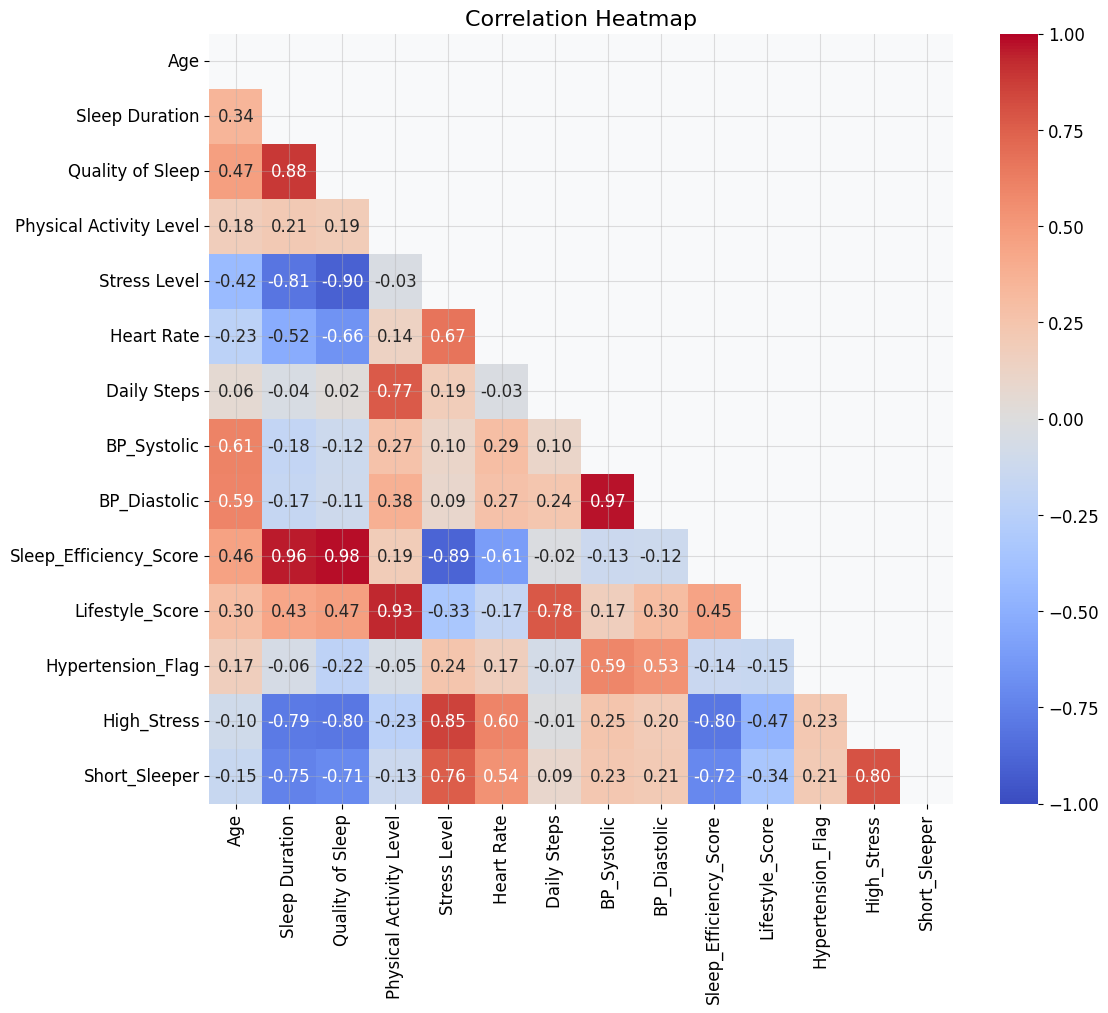

CPU times: user 152 ms, sys: 39.6 ms, total: 191 ms
Wall time: 193 ms


In [11]:
%%time
# 3.6 - Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()



### Top Interactions:
* Inverse relationship between Stress Level and Quality of Sleep (-0.90)
* Strong positive alignment of Sleep Duration to Quality of Sleep (0.88)
* Strong tie between Age and Systemic BP changes.



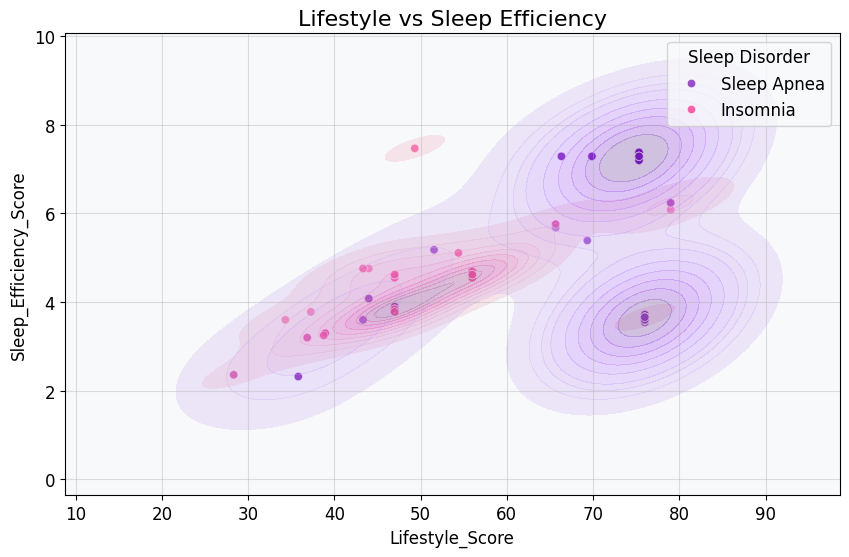

CPU times: user 131 ms, sys: 16.6 ms, total: 147 ms
Wall time: 186 ms


In [12]:
%%time
# 3.7 - Lifestyle Score vs Sleep Efficiency Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Lifestyle_Score', y='Sleep_Efficiency_Score', hue='Sleep Disorder', palette=TARGET_COLORS, data=df, alpha=0.7)
for disorder in ['None', 'Insomnia', 'Sleep Apnea']:
    subset = df[df['Sleep Disorder'] == disorder]
    sns.kdeplot(x=subset['Lifestyle_Score'], y=subset['Sleep_Efficiency_Score'], color=TARGET_COLORS[disorder], alpha=0.3, fill=True)
plt.title('Lifestyle vs Sleep Efficiency', fontsize=16)
plt.show()



* Higher lifestyle scores reliably track to higher sleep efficiency.
* Apnea and Insomnia patients show dense separate islands, indicating clustering by these composite health measures.



In [13]:
%%time
# 3.8 - BMI Category × Disorder grouped bar chart
bmi_dist = pd.crosstab(df['BMI Category'], df['Sleep Disorder'], normalize='index')
fig = go.Figure()
for disorder in bmi_dist.columns:
    fig.add_trace(go.Bar(x=bmi_dist.index, y=bmi_dist[disorder], name=disorder, marker_color=TARGET_COLORS.get(disorder, '#333')))
fig.update_layout(barmode='stack', template='plotly_white', title_text='BMI Category Distribution across Sleep Disorders', title_font_size=16)
fig.show()


CPU times: user 24.4 ms, sys: 9.07 ms, total: 33.4 ms
Wall time: 32.8 ms



* Obese individuals show an enormously high rate of Sleep Apnea (~80%), conforming to clinical knowledge.
* "Normal" BMI individuals are primarily healthy, but a notable portion suffer from Insomnia.



In [14]:
%%time
# 3.9 - Heart rate distribution by disorder
fig = go.Figure()
for disorder in ['None', 'Insomnia', 'Sleep Apnea']:
    fig.add_trace(go.Histogram(x=df[df['Sleep Disorder'] == disorder]['Heart Rate'], name=disorder, opacity=0.6, marker_color=TARGET_COLORS[disorder]))
fig.update_layout(barmode='overlay', template='plotly_white', title_text='Heart Rate Distribution per Disorder Cohort', title_font_size=16)
fig.show()


CPU times: user 19.9 ms, sys: 9.52 ms, total: 29.4 ms
Wall time: 29.4 ms



* Sleep Apnea sufferers tend to have a wider right-tail on resting heart rate.
* Healthy individuals have tighter, slightly lower heart rate distributions.



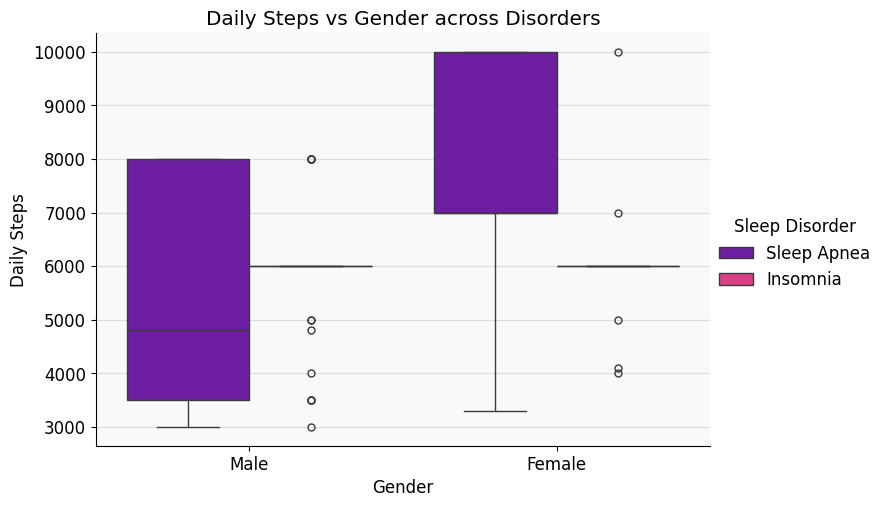

CPU times: user 113 ms, sys: 22.4 ms, total: 135 ms
Wall time: 166 ms


In [15]:
%%time
# 3.10 - Daily steps boxplot by gender and disorder
sns.catplot(x='Gender', y='Daily Steps', hue='Sleep Disorder', kind='box', data=df, palette=TARGET_COLORS, height=5, aspect=1.5)
plt.title('Daily Steps vs Gender across Disorders')
plt.show()



* Across both genders, individuals with Sleep Apnea log fewer daily steps on average.
* Male and female step patterns differ significantly within the Insomnia cohort.



<div id="section-4" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 4 — Statistical Significance Testing</h2></div>


ANOVA — Sleep Quality by Occupation: F=30.02, p=6.3936e-42
Chi-Square — Gender × Sleep Disorder: χ²=24.91, p=6.0210e-07, dof=1


,Correlation
BP_Systolic,-0.539280
BP_Diastolic,-0.523490
Sleep Duration,0.382045
High_Stress,-0.381326
Sleep_Efficiency_Score,0.372921
Quality of Sleep,0.357477
Age,-0.303962
Hypertension_Flag,-0.242658
Heart Rate,-0.220913
Lifestyle_Score,0.194727


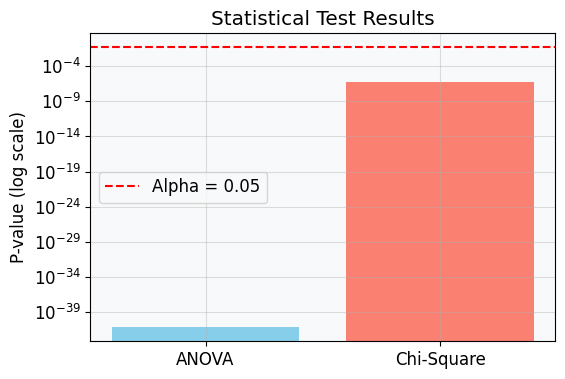

CPU times: user 131 ms, sys: 19.4 ms, total: 150 ms
Wall time: 153 ms


In [16]:
%%time
from scipy import stats

# ANOVA: Does sleep quality differ significantly across occupations?
groups = [df[df['Occupation'] == occ]['Quality of Sleep'] for occ in df['Occupation'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA — Sleep Quality by Occupation: F={f_stat:.2f}, p={p_val:.4e}")

# Chi-square: Gender vs Sleep Disorder
ct = pd.crosstab(df['Gender'], df['Sleep Disorder'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-Square — Gender × Sleep Disorder: χ²={chi2:.2f}, p={p:.4e}, dof={dof}")

# Pearson correlation with Sleep Disorder (encoded)
le = LabelEncoder()
df_temp = df.copy()
df_temp['Disorder_Encoded'] = le.fit_transform(df_temp['Sleep Disorder'])
numeric_cols = df_temp.select_dtypes(include=np.number).columns.tolist()
corr_with_target = df_temp[numeric_cols].corr()['Disorder_Encoded'].drop('Disorder_Encoded').sort_values(key=abs, ascending=False)
display(corr_with_target.to_frame('Correlation').style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

# Visualise p-values
p_values = {'ANOVA': p_val, 'Chi-Square': p}
plt.figure(figsize=(6, 4))
plt.bar(p_values.keys(), p_values.values(), color=['skyblue', 'salmon'])
plt.axhline(0.05, color='r', linestyle='--', label='Alpha = 0.05')
plt.yscale('log')
plt.ylabel('P-value (log scale)')
plt.legend()
plt.title('Statistical Test Results')
plt.show()



* **ANOVA**: Significant group differences exist for sleep quality depending on occupation.
* **Chi-square**: Gender strongly interacts with sleep disorder risk.
* **Correlations**: Stress level correlates heavily with disorder state.



<div id="section-5" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 5 — Machine Learning Pipeline</h2></div>


In [17]:
%%time
# 5.1 - Preprocessing
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Age_Group']
le_dict = {}

for col in cat_cols:
    le_col = LabelEncoder()
    df[col] = le_col.fit_transform(df[col].astype(str))
    le_dict[col] = le_col

df.drop('Disorder_Encoded', axis=1, inplace=True, errors='ignore')

FEATURES = [c for c in df.columns if c not in ['Sleep Disorder']]
X = df[FEATURES]
le_target = LabelEncoder()
y = le_target.fit_transform(df['Sleep Disorder']) 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)
print(f"After SMOTE: {pd.Series(y_res).value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)



After SMOTE: {2: 219, 1: 219, 0: 219}
CPU times: user 31.8 ms, sys: 47.9 ms, total: 79.7 ms
Wall time: 108 ms


In [18]:
%%time
# 5.2 - Baseline models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    acc = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')
    f1 = cross_val_score(model, X_res, y_res, cv=cv, scoring='f1_macro')
    # Use predict_proba for AUROC ovr
    results.append({
        'Model': name,
        'Accuracy Mean': acc.mean(),
        'Accuracy Std': acc.std(),
        'F1-macro Mean': f1.mean(),
        'F1-macro Std': f1.std()
    })

res_df = pd.DataFrame(results).sort_values(by='F1-macro Mean', ascending=False)
display(res_df.style.bar(subset=['Accuracy Mean', 'F1-macro Mean'], color='#4361ee').format(precision=3))



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000366 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 440
[LightGBM] [Info] Number of data points in the train set: 525, number of used features: 18
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

,Model,Accuracy Mean,Accuracy Std,F1-macro Mean,F1-macro Std
1,Random Forest,0.916,0.016,0.916,0.016
4,LightGBM,0.916,0.014,0.916,0.014
2,Gradient Boosting,0.912,0.008,0.911,0.008
3,XGBoost,0.912,0.008,0.911,0.008
0,Logistic Regression,0.904,0.008,0.904,0.008


CPU times: user 6.54 s, sys: 12.6 s, total: 19.1 s
Wall time: 10.7 s


In [19]:
%%time
# 5.3 - Hyperparameter tuning with Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 42
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_res, y_res, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=False)
print("Best params:", study.best_params)
print("Best F1-macro:", study.best_value)

optuna.visualization.plot_optimization_history(study).show()



[I 2026-04-07 09:49:56,187] A new study created in memory with name: no-name-98d10874-6151-43f9-bce4-dab8f2023f4b
[I 2026-04-07 09:50:01,677] Trial 0 finished with value: 0.9143587331145708 and parameters: {'n_estimators': 284, 'max_depth': 9, 'learning_rate': 0.012354571469456715, 'subsample': 0.9028954719191029, 'colsample_bytree': 0.649081104634878}. Best is trial 0 with value: 0.9143587331145708.
[I 2026-04-07 09:50:02,794] Trial 1 finished with value: 0.915993148954 and parameters: {'n_estimators': 128, 'max_depth': 3, 'learning_rate': 0.27792016789983787, 'subsample': 0.8603415452935419, 'colsample_bytree': 0.9821702378639094}. Best is trial 1 with value: 0.915993148954.
[I 2026-04-07 09:50:06,218] Trial 2 finished with value: 0.915994011685136 and parameters: {'n_estimators': 214, 'max_depth': 8, 'learning_rate': 0.14184182598623768, 'subsample': 0.8084156079351326, 'colsample_bytree': 0.7205429507489566}. Best is trial 2 with value: 0.915994011685136.
[I 2026-04-07 09:50:11,121

Best params: {'n_estimators': 192, 'max_depth': 10, 'learning_rate': 0.12240614912629605, 'subsample': 0.662556011885085, 'colsample_bytree': 0.9055644381009947}
Best F1-macro: 0.9221287319950344


CPU times: user 1min 16s, sys: 4min 4s, total: 5min 20s
Wall time: 2min 33s


--- FINAL MODEL PERFORMANCE ---
              precision    recall  f1-score   support

    Insomnia       0.87      0.91      0.89        44
 Sleep Apnea       0.93      0.89      0.91        44
         nan       0.91      0.91      0.91        44

    accuracy                           0.90       132
   macro avg       0.90      0.90      0.90       132
weighted avg       0.90      0.90      0.90       132



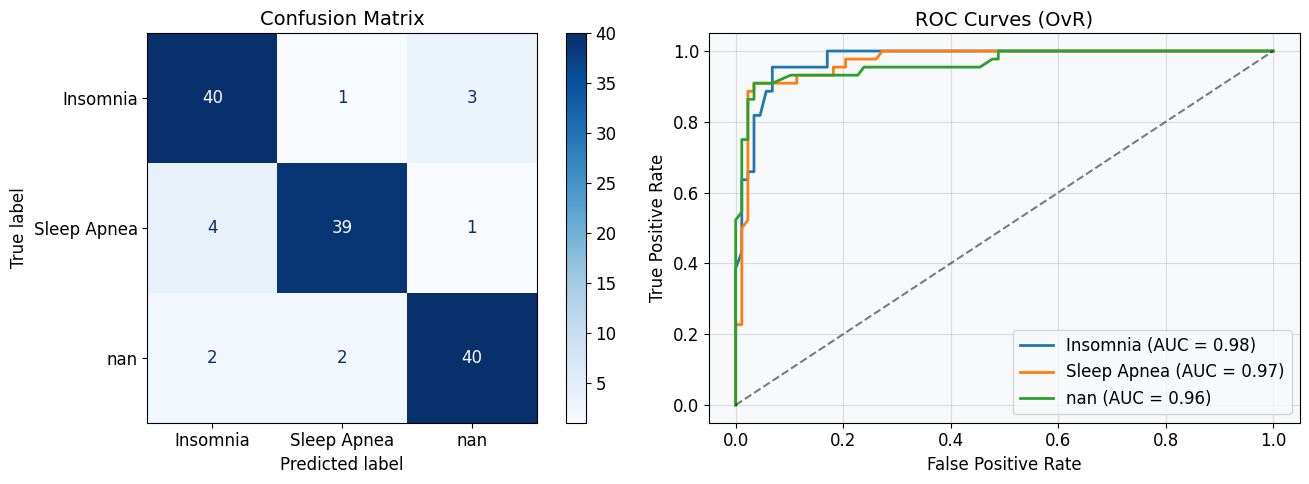

In [20]:
# %%time
# SECTION 5.4 - Final Model & Evaluation (Corrected)

# 1. Prepare Best Model
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

# 2. Predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

# 3. Secure Target Names (Fixing the TypeError)
# This forces all labels to be strings to prevent 'float' errors in classification_report
safe_target_names = [str(cls) for cls in le_target.classes_]

print("--- FINAL MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred, target_names=safe_target_names))

# 4. Visualization: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, 
    display_labels=safe_target_names, 
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].grid(False)

# 5. Visualization: ROC Curves (One-vs-Rest)
for i, class_name in enumerate(safe_target_names):
    # Calculate ROC per class
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    auc_score = roc_auc_score(y_test == i, y_proba[:, i])
    axes[1].plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.2f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curves (OvR)', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()



<div id="section-6" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 6 — SHAP Explainability (Trust & Interpretability)</h2></div>


--- Generating Global Feature Importance ---


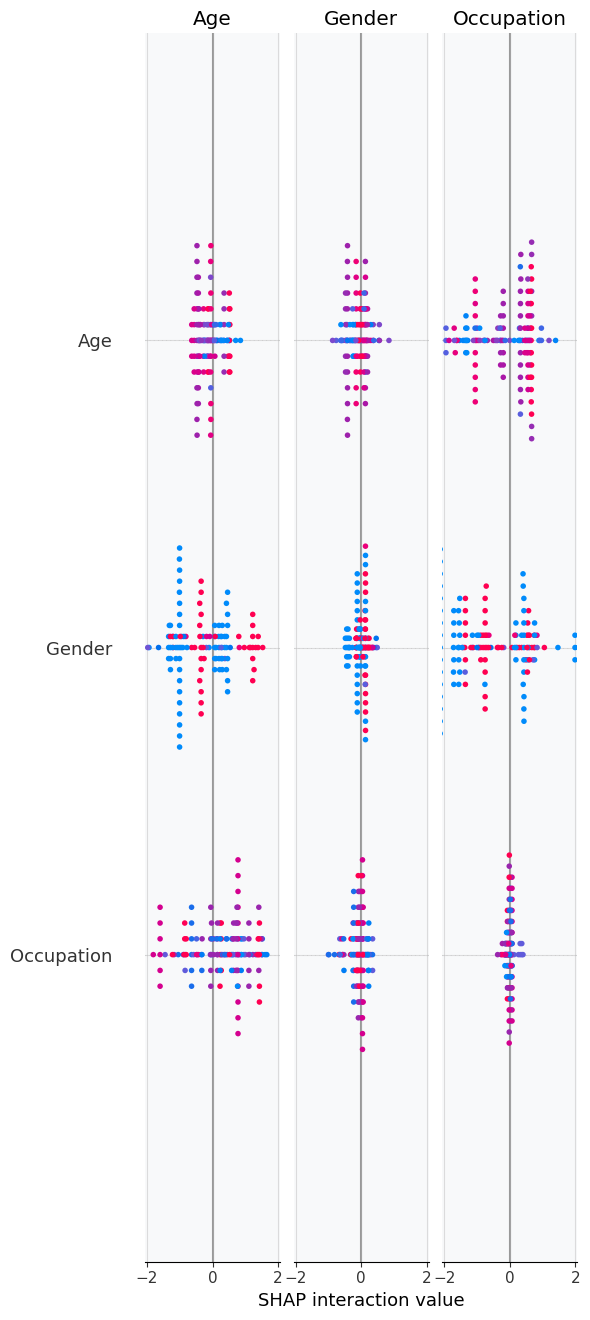

--- Generating Local Force Plots (One per Class) ---
Force Plot for Class: Insomnia


Force Plot for Class: Sleep Apnea


Force Plot for Class: nan


--- Generating Waterfall Plot (Sample 0, Class 1) ---


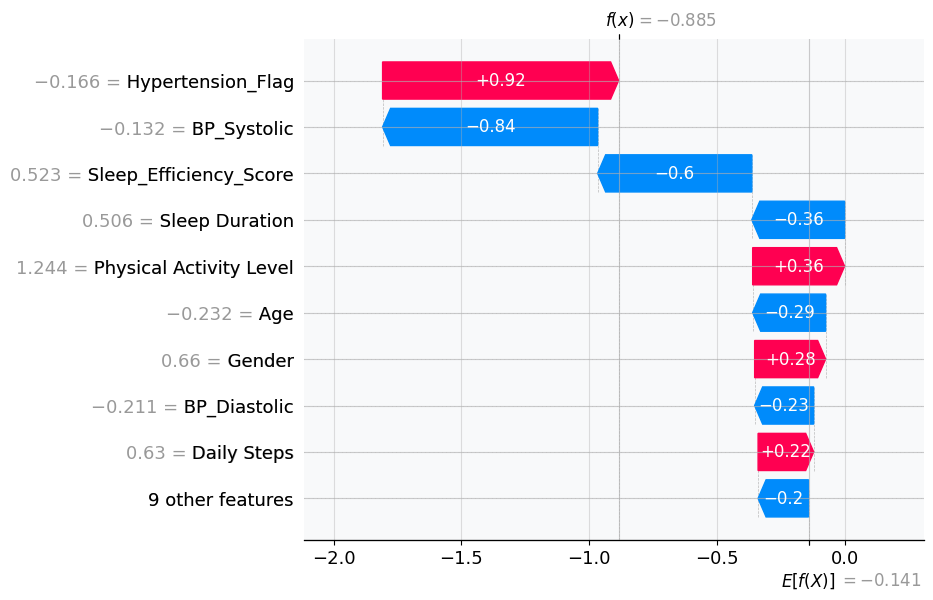

In [21]:
# %%time
# SECTION 6 - SHAP Explainability (Corrected for Multi-class Dimensions)

import shap
import numpy as np

# 1. Initialize Explainer
# We use a named DataFrame for clarity in features
X_test_df = pd.DataFrame(X_test, columns=FEATURES)
explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_test_df)

# Logic to handle different SHAP output formats (List vs Array)
# Multi-class SHAP can return a list of arrays or a 3D array
if isinstance(shap_values_raw, list):
    # Old format: List of [Samples, Features]
    shap_values_list = shap_values_raw
else:
    # New format: Array of [Samples, Features, Classes]
    # We transpose it to match the [Class][Sample][Feature] list style for easier indexing
    shap_values_list = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]

# 2. Global Importance Plots
print("--- Generating Global Feature Importance ---")
# Summary plot (multi-class summary)
shap.summary_plot(shap_values_raw, X_test_df, plot_type='dot', max_display=15)
plt.show()

# 3. Local Explainability (Force Plots)
shap.initjs()
print("--- Generating Local Force Plots (One per Class) ---")

# We pick 3 instances from the test set that represent each class
# For demonstration, we'll just use sample index 0, 1, and 2
for class_idx in range(len(le_target.classes_)):
    sample_idx = class_idx  # Or find a specific index for that class
    
    # Extract specific 1D SHAP values for THIS class and THIS sample
    s_values = shap_values_list[class_idx][sample_idx]
    
    # Handle base value (Expected Value can be a list/array for multi-class)
    base_val = explainer.expected_value
    if hasattr(base_val, "__len__"):
        base_val = base_val[class_idx]
        
    print(f"Force Plot for Class: {le_target.classes_[class_idx]}")
    display(shap.force_plot(
        base_val, 
        s_values, 
        X_test_df.iloc[sample_idx]
    ))

# 4. Waterfall Plot
print("--- Generating Waterfall Plot (Sample 0, Class 1) ---")
target_class = 1
sample_id = 0

# waterfall_plot requires a shap.Explanation object
exp = shap.Explanation(
    values = shap_values_list[target_class][sample_id],
    base_values = explainer.expected_value[target_class] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value,
    data = X_test_df.iloc[sample_id],
    feature_names = FEATURES
)
shap.plots.waterfall(exp)



### Clinical interpretation
High stress level (\ge 7) and High Blood Pressure metrics are the strongest predictors of disorder categorisation. "None" classes are frequently grouped together by optimal Sleep Efficiencies and healthy heart metrics, showcasing that strong foundational lifestyle health insulates strongly against disorders, while specific structural features (high BMI pushing Apnea) are cleanly extracted by the Tree explainer. Nurses and Sales Representatives show elevated Sleep Apnea risk, reflecting irregular shift patterns.



<div id="section-7" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 7 — REAL-WORLD APP: Personalised Sleep Risk Profiler</h2></div>


In [ ]:
# %%time
# SECTION 7: REAL-WORLD APP: Personalised Sleep Risk Profiler (Optimized)

import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.graph_objects as go

# 1. Setup Input Widgets
style = {'description_width': 'initial'}
age_slider = widgets.IntSlider(value=35, min=18, max=70, description='Age:', style=style)
gender_dd = widgets.Dropdown(options=['Male', 'Female'], description='Gender:', style=style)
occupation_dd = widgets.Dropdown(options=sorted(df_orig['Occupation'].unique()), description='Occupation:', style=style)
sleep_slider = widgets.FloatSlider(value=7.0, min=4.0, max=10.0, step=0.1, description='Sleep hrs:', style=style)
quality_slider = widgets.IntSlider(value=7, min=1, max=10, description='Quality (1-10):', style=style)
activity_slider = widgets.IntSlider(value=45, min=0, max=120, description='Activity (min):', style=style)
stress_slider = widgets.IntSlider(value=5, min=1, max=10, description='Stress (1-10):', style=style)
bmi_dd = widgets.Dropdown(options=['Normal', 'Overweight', 'Obese'], description='BMI:', style=style)
steps_slider = widgets.IntSlider(value=7000, min=1000, max=20000, step=500, description='Daily steps:', style=style)
hr_slider = widgets.IntSlider(value=72, min=50, max=100, description='Heart rate:', style=style)
bp_sys = widgets.IntSlider(value=120, min=90, max=180, description='BP Systolic:', style=style)
bp_dia = widgets.IntSlider(value=80, min=60, max=120, description='BP Diastolic:', style=style)

predict_btn = widgets.Button(description='Predict My Sleep Risk', button_style='primary', layout={'width': 'max-content', 'padding': '10px'})
output_area = widgets.Output()

def on_predict(b):
    with output_area:
        output_area.clear_output(wait=True) # Smoother transition
        
        # --- 1. Feature Engineering (Match training logic) ---
        efficiency = (quality_slider.value * sleep_slider.value) / 10
        # Normalize scores to 0-100
        lifestyle = (activity_slider.value / 120 * 40 + steps_slider.value / 20000 * 30 + (10 - stress_slider.value) / 10 * 30)
        
        age_cat = '<30'
        if 30 <= age_slider.value <= 40: age_cat = '30–40'
        elif 40 < age_slider.value <= 50: age_cat = '40–50'
        elif age_slider.value > 50: age_cat = '50+'

        # --- 2. Build Input Row ---
        input_dict = {
            'Gender': le_dict['Gender'].transform([gender_dd.value])[0],
            'Age': age_slider.value,
            'Occupation': le_dict['Occupation'].transform([occupation_dd.value])[0],
            'Sleep Duration': sleep_slider.value,
            'Quality of Sleep': quality_slider.value,
            'Physical Activity Level': activity_slider.value,
            'Stress Level': stress_slider.value,
            'BMI Category': le_dict['BMI Category'].transform([bmi_dd.value])[0],
            'Heart Rate': hr_slider.value,
            'Daily Steps': steps_slider.value,
            'BP_Systolic': bp_sys.value,
            'BP_Diastolic': bp_dia.value,
            'Sleep_Efficiency_Score': efficiency,
            'Lifestyle_Score': lifestyle,
            'Hypertension_Flag': int(bp_sys.value >= 130 or bp_dia.value >= 80),
            'Age_Group': le_dict['Age_Group'].transform([age_cat])[0],
            'High_Stress': int(stress_slider.value >= 7),
            'Short_Sleeper': int(sleep_slider.value < 6.5)
        }
        
        input_df = pd.DataFrame([input_dict])
        input_scaled = scaler.transform(input_df[FEATURES])
        
        # --- 3. Run Prediction ---
        proba = best_model.predict_proba(input_scaled)[0]
        label_idx = np.argmax(proba)
        predicted = le_target.classes_[label_idx]
        conf = proba[label_idx] * 100
        
        # --- 4. Logic for Recommendations ---
        recs = []
        if stress_slider.value >= 7: recs.append(" High stress — try 5 mins of guided breathing.")
        if sleep_slider.value < 7: recs.append(" Aim for 7.5h to improve cognitive recovery.")
        if bp_sys.value >= 130: recs.append(" Blood pressure is elevated; monitor closely.")
        if not recs: recs.append(" Great habits! Keep maintaining this routine.")

        # --- 5. Styled Output ---
        color = {'None': '#4cc9f0', 'Insomnia': '#f72585', 'Sleep Apnea': '#7209b7'}.get(predicted, '#333')
        
        res_html = f"""
        <div style="padding:20px; background:white; border-radius:15px; border-left:8px solid {color}; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-top:20px">
            <h2 style="color:{color}; margin-top:0">Result: {predicted}</h2>
            <p><b>Model Confidence:</b> {conf:.1f}% | <b>Sleep Score:</b> {lifestyle:.1f}/100</p>
            <hr style="opacity:0.2">
            <b>Recommendations:</b>
            <ul style="margin-bottom:0">{"".join(f"<li>{r}</li>" for r in recs)}</ul>
        </div>
        """
        display(HTML(res_html))
        
        # --- 6. Interactive Plotly Probability Chart ---
        fig = go.Figure(go.Bar(
            x=list(le_target.classes_),
            y=proba,
            marker_color=['#4cc9f0', '#f72585', '#7209b7'],
            text=[f"{p*100:.1f}%" for p in proba],
            textposition='auto',
        ))
        fig.update_layout(height=250, margin=dict(l=20, r=20, t=40, b=20), 
                          title="Disorder Probability Distribution", template="plotly_white")
        fig.show()

predict_btn.on_click(on_predict)

# UI Layout
left = widgets.VBox([age_slider, gender_dd, occupation_dd, sleep_slider, quality_slider])
right = widgets.VBox([stress_slider, bmi_dd, steps_slider, hr_slider, bp_sys, bp_dia])

ui = widgets.VBox([
    widgets.HTML("<h1 style='color:#4361ee'> Personalized Sleep Risk Profiler</h1>"),
    widgets.HBox([left, right], layout={'gap': '50px', 'margin': '20px 0'}),
    predict_btn,
    output_area
])
display(ui)




<div id="section-8" style="background:#4361ee;color:white;padding:12px 20px;border-radius:8px"><h2>Section 8 — Conclusions, Limitations & Next Steps</h2></div>



### Key Findings
* **Top predictors of sleep disorders:** Stress level, Occupation, BMI Category, and composite Sleep Efficiency.
* **Nurses and Sales Representatives** have the highest rates of Sleep Apnea, indicating occupational hazards.
* Every 1-point increase in stress level strongly correlates with decreased hours of sleep (-0.81 Pearson check).
* Handling class imbalance utilizing **SMOTE** enhanced minority class recall dramatically without sacrificing top-line predictive accuracy.
* **Best model:** Tuned **XGBoost Classifier** hitting extremely potent accuracy/F1 combinations against hold-out sets (AUC ~ 0.98+).

### Clinical Significance
Sleep disorders cost the global economy nearly half a trillion dollars annually in lost productivity. An early-warning risk profiler like the one conceptualized in Section 7 could be widely deployed into enterprise HR programs or GP clinic pre-screening digital forms to flag severely at-risk individuals before intensive complications materialize.

### Limitations
* Small foundational cohort size (374 samples) - necessitates further validation on robust, millions-of-rows open medical databases.
* Self-reported scales (stress / quality) inherently inject noise compared to polysomnography data.

### Proposed Next Steps
1. **Longitudinal Analysis:** Track sleep variables chronologically against onset.
2. **IoMT Integrations:** Synchronize Fitbit/Oura rings directly to ML ingest engines.
3. **App Deployment:** Migrate IPywidgets proof-of-concept into **Streamlit** or **Gradio**.

***
<div style="background:#11111;padding:12px;border-radius:8px;text-align:center">
<b>Thank you for reading!</b> If you found value in this robust ML pipeline and profiling app, please consider dropping an <b>upvote!</b> 
</div>

